# 🛍️ Customer Intelligence System using Machine Learning

Developed an end-to-end Customer Intelligence System that predicts customer behavior and segments customers into meaningful groups using both supervised and unsupervised machine learning techniques.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix
from sklearn.cluster import KMeans, DBSCAN

import warnings
warnings.filterwarnings('ignore')

# Set plot style
sns.set_theme(style="whitegrid")


## Phase 1: Data Preprocessing

In [2]:
# Load the dataset
df = pd.read_csv('customer/marketing_campaign.csv', sep='	')

# Display basic info
print("Dataset Shape:", df.shape)
df.head()


Dataset Shape: (2240, 29)


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [3]:
# Check for missing values
print("Missing values before cleaning:\n", df.isnull().sum()[df.isnull().sum() > 0])

# Fill missing values in Income with median
df['Income'].fillna(df['Income'].median(), inplace=True)

# Remove duplicates
df.drop_duplicates(inplace=True)

# Outlier Detection & Removal (Income > 600,000 is likely an outlier)
df = df[df['Income'] < 600000]

print("\nData Shape after cleaning:", df.shape)


Missing values before cleaning:
 Income    24
dtype: int64

Data Shape after cleaning: (2239, 29)


In [4]:
# Create Customer Age
df['Age'] = 2024 - df['Year_Birth'] # Assuming current year context

# Total Spending Score (sum of all Mnt features)
mnt_cols = [col for col in df.columns if 'Mnt' in col]
df['Spending_Score'] = df[mnt_cols].sum(axis=1)

# Total Purchases
purchases_cols = [col for col in df.columns if 'Purchases' in col]
df['Total_Purchases'] = df[purchases_cols].sum(axis=1)

# Total Children
df['Total_Children'] = df['Kidhome'] + df['Teenhome']

# Drop columns that are no longer needed or less useful
df.drop(['ID', 'Z_CostContact', 'Z_Revenue', 'Year_Birth', 'Dt_Customer'], axis=1, inplace=True)

df.head()


,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Age,Spending_Score,Total_Purchases,Total_Children
0,Graduation,Single,58138.0,0,0,58,635,88,546,172,...,0,0,0,0,0,1,67,1617,25,0
1,Graduation,Single,46344.0,1,1,38,11,1,6,2,...,0,0,0,0,0,0,70,27,6,2
2,Graduation,Together,71613.0,0,0,26,426,49,127,111,...,0,0,0,0,0,0,59,776,21,0
3,Graduation,Together,26646.0,1,0,26,11,4,20,10,...,0,0,0,0,0,0,40,53,8,1
4,PhD,Married,58293.0,1,0,94,173,43,118,46,...,0,0,0,0,0,0,43,422,19,1


In [5]:
# Label Encoding for categorical features
le = LabelEncoder()
df['Education'] = le.fit_transform(df['Education'])

# One-Hot Encoding for Marital_Status
df = pd.get_dummies(df, columns=['Marital_Status'], drop_first=True)

# Separate features for clustering/classification
X = df.drop(['Response'], axis=1)
y = df['Response']

# Feature Scaling
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
X_scaled.head()


,Education,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,...,Spending_Score,Total_Purchases,Total_Children,Marital_Status_Alone,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Marital_Status_YOLO
0,-0.350229,0.288446,-0.824769,-0.930282,0.306624,0.983339,1.551126,1.679196,2.461517,1.476020,...,1.678944,1.320381,-1.264195,-0.036629,-0.339993,-0.792694,1.914310,-0.590589,-0.18872,-0.029901
1,-0.350229,-0.262524,1.033035,0.906491,-0.384051,-0.870826,-0.636311,-0.713430,-0.650588,-0.631700,...,-0.961639,-1.154628,1.396080,-0.036629,-0.339993,-0.792694,1.914310,-0.590589,-0.18872,-0.029901
2,-0.350229,0.917946,-0.824769,-0.930282,-0.798456,0.362313,0.570551,-0.177305,1.344820,-0.147167,...,0.282258,0.799327,-1.264195,-0.036629,-0.339993,-0.792694,-0.522381,1.693225,-0.18872,-0.029901
3,-0.350229,-1.182738,1.033035,-0.930282,-0.798456,-0.870826,-0.560882,-0.651399,-0.504136,-0.583247,...,-0.918460,-0.894101,0.065942,-0.036629,-0.339993,-0.792694,-0.522381,1.693225,-0.18872,-0.029901
4,1.427918,0.295687,1.033035,-0.930282,1.549838,-0.389456,0.419693,-0.217182,0.154898,-0.001807,...,-0.305645,0.538799,0.065942,-0.036629,-0.339993,1.261521,-0.522381,-0.590589,-0.18872,-0.029901


## Phase 2: Exploratory Data Analysis (EDA)

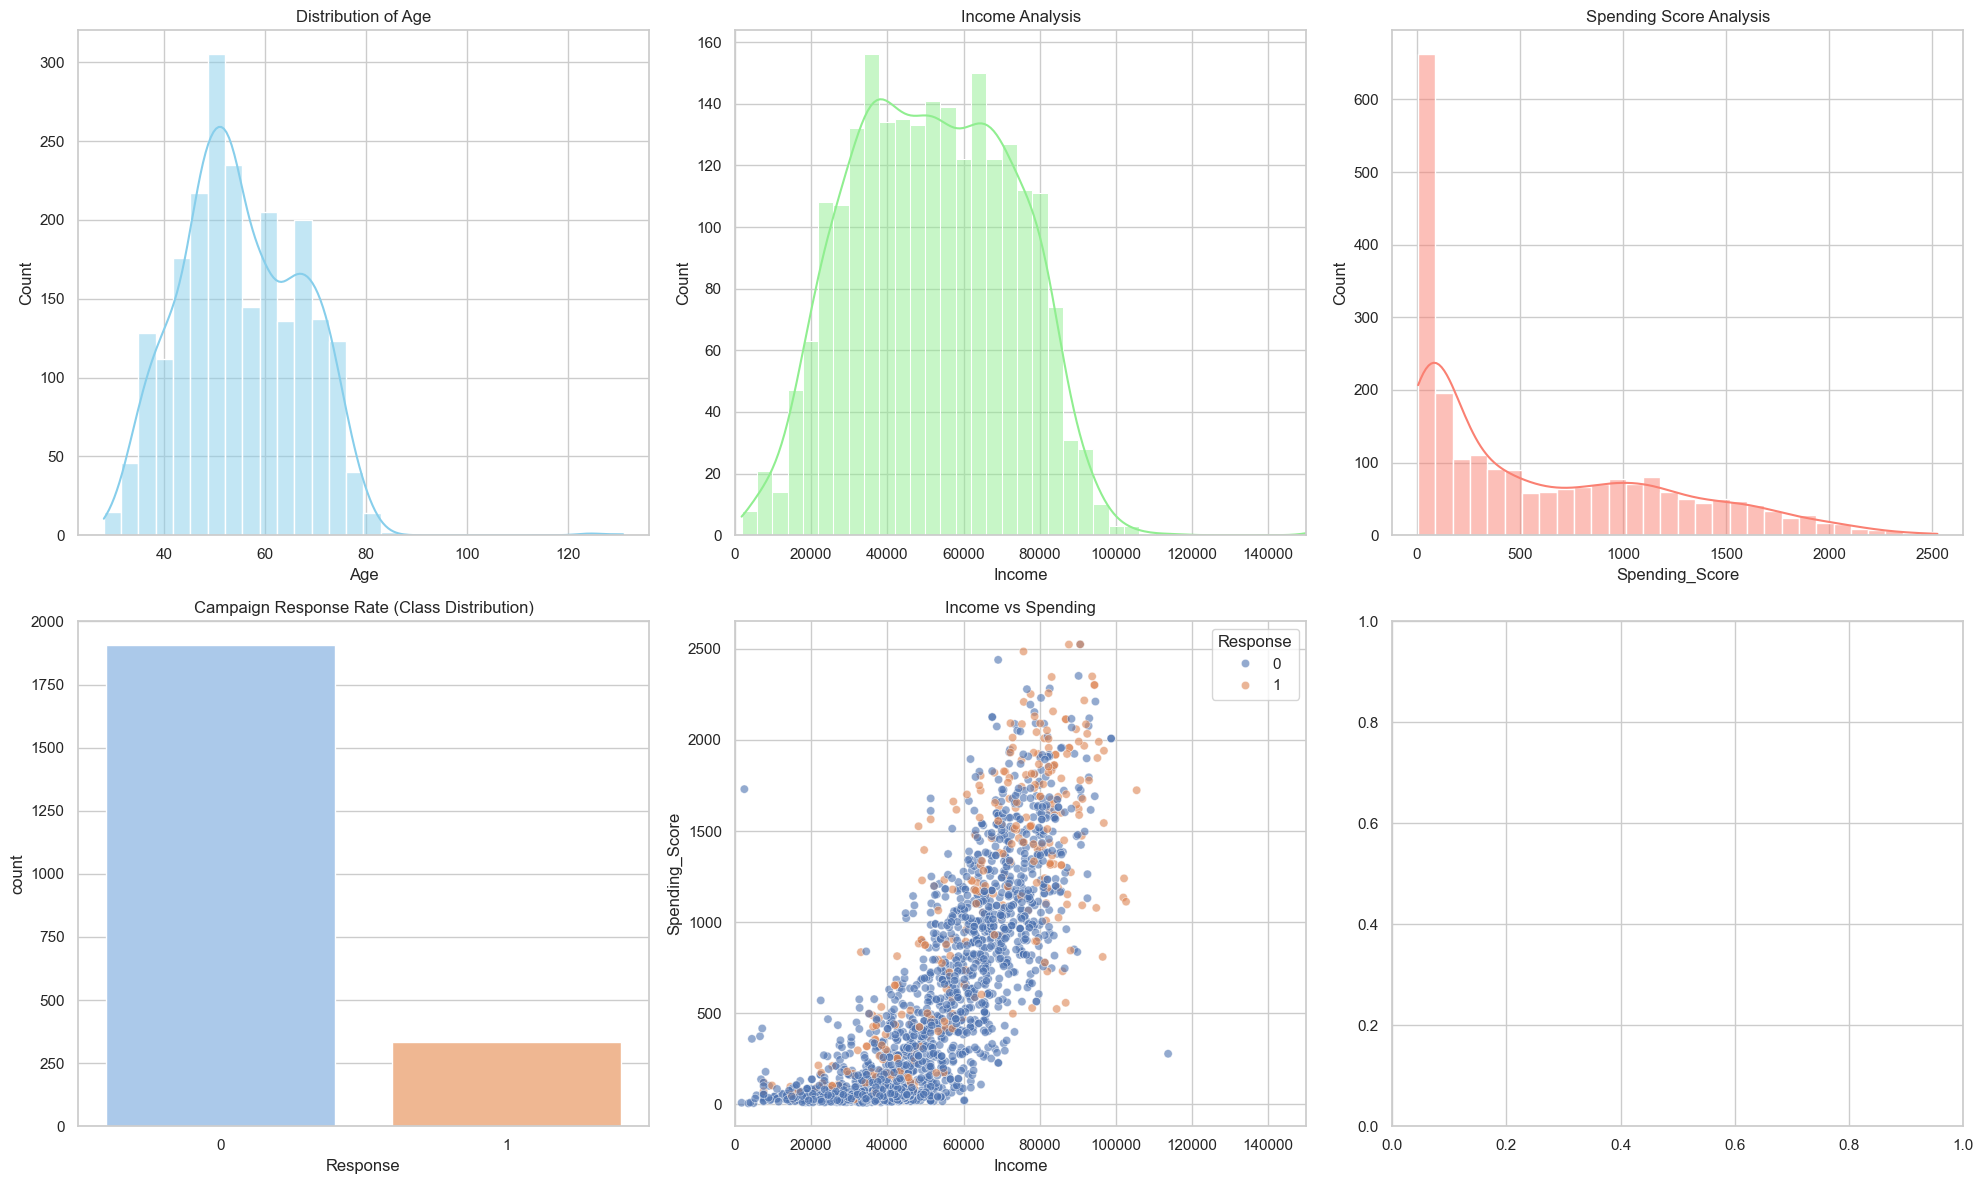

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# 1. Distribution of Age
sns.histplot(df['Age'], bins=30, kde=True, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Distribution of Age')

# 2. Income Analysis
sns.histplot(df['Income'], bins=40, kde=True, ax=axes[0, 1], color='lightgreen')
axes[0, 1].set_title('Income Analysis')
axes[0, 1].set_xlim(0, 150000)

# 3. Spending Score Analysis
sns.histplot(df['Spending_Score'], bins=30, kde=True, ax=axes[0, 2], color='salmon')
axes[0, 2].set_title('Spending Score Analysis')

# 4. Campaign Response Rate
sns.countplot(x='Response', data=df, ax=axes[1, 0], palette='pastel')
axes[1, 0].set_title('Campaign Response Rate (Class Distribution)')

# 5. Income vs Spending
sns.scatterplot(x='Income', y='Spending_Score', hue='Response', data=df, ax=axes[1, 1], alpha=0.6)
axes[1, 1].set_title('Income vs Spending')
axes[1, 1].set_xlim(0, 150000)

plt.tight_layout()
plt.show()


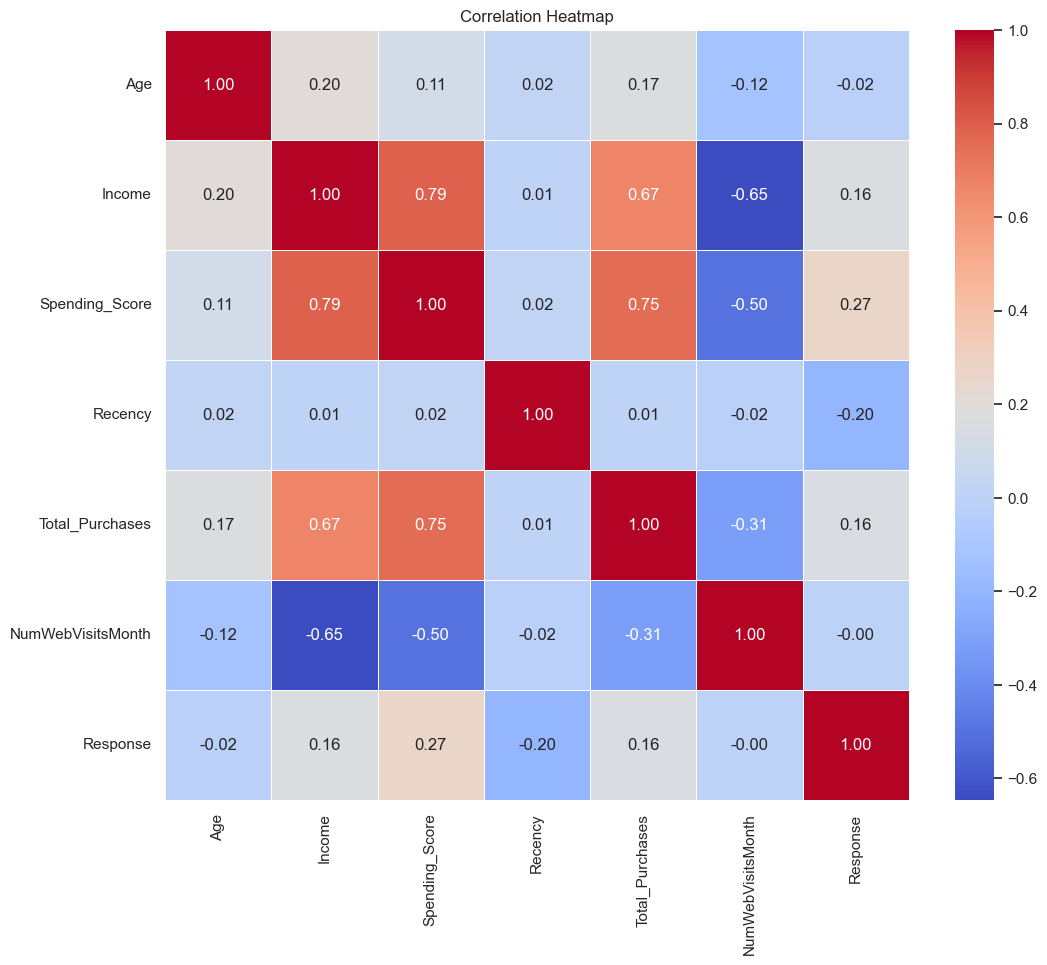

In [7]:
plt.figure(figsize=(12, 10))
# Select only numeric columns for correlation heatmap
numeric_df = df.select_dtypes(include=[np.number])
# Select key features to prevent cluttered heatmap
key_features = ['Age', 'Income', 'Spending_Score', 'Recency', 'Total_Purchases', 'NumWebVisitsMonth', 'Response']
sns.heatmap(numeric_df[key_features].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()


## Phase 3: Classification Models

Objective: Predict whether a customer will respond to a campaign.

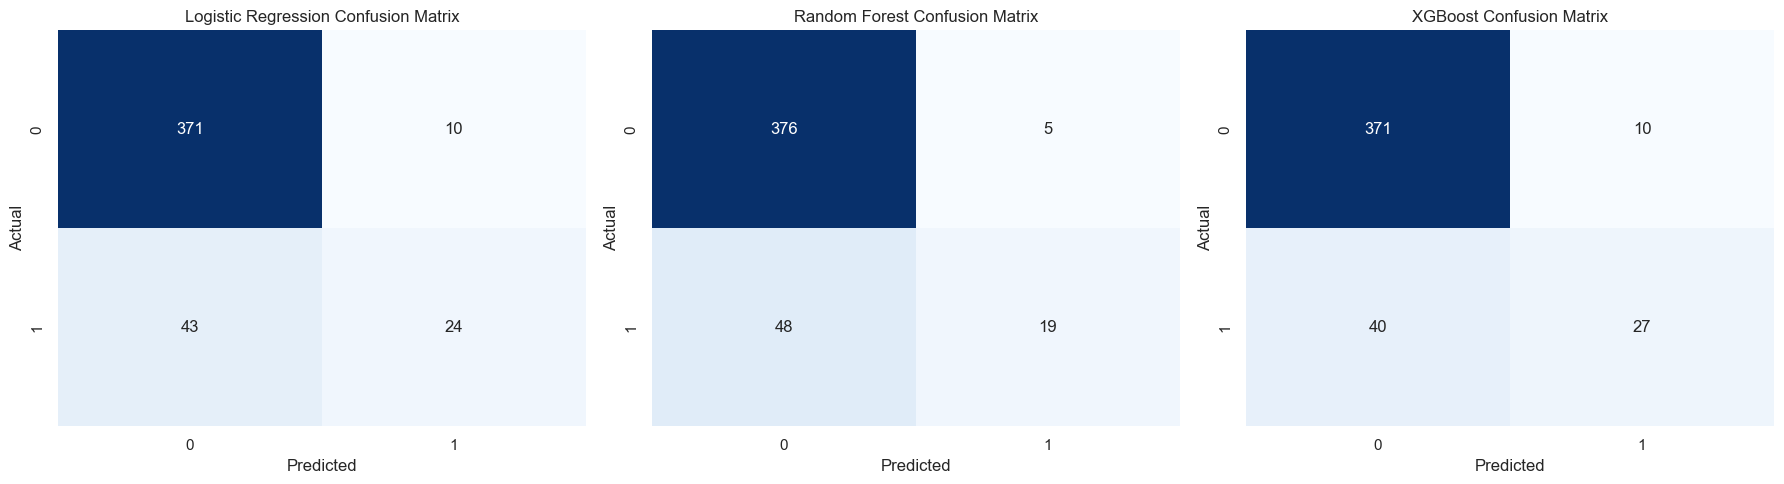

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
2,XGBoost,0.888393,0.729730,0.402985,0.519231,0.897187
0,Logistic Regression,0.881696,0.705882,0.358209,0.475248,0.894014
1,Random Forest,0.881696,0.791667,0.283582,0.417582,0.883672


In [8]:
# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

# Initialize models
models = {
    'Logistic Regression': LogisticRegression(),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

results = []

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, model) in enumerate(models.items()):
    # Train
    model.fit(X_train, y_train)
    # Predict
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)
    
    results.append([name, acc, prec, rec, f1, roc_auc])
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], cbar=False)
    axes[idx].set_title(f'{name} Confusion Matrix')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

plt.tight_layout()
plt.show()

# Display Results
results_df = pd.DataFrame(results, columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC'])
results_df.sort_values(by='ROC-AUC', ascending=False)


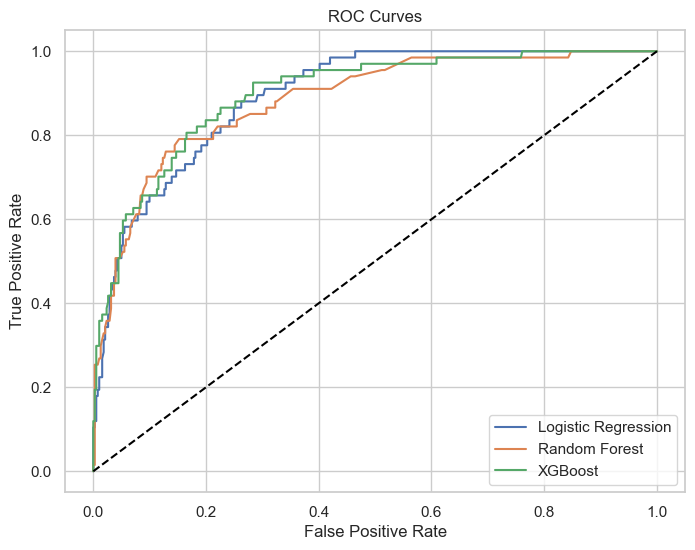

In [9]:
plt.figure(figsize=(8, 6))

for name, model in models.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{name}')

plt.plot([0, 1], [0, 1], color='black', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.show()


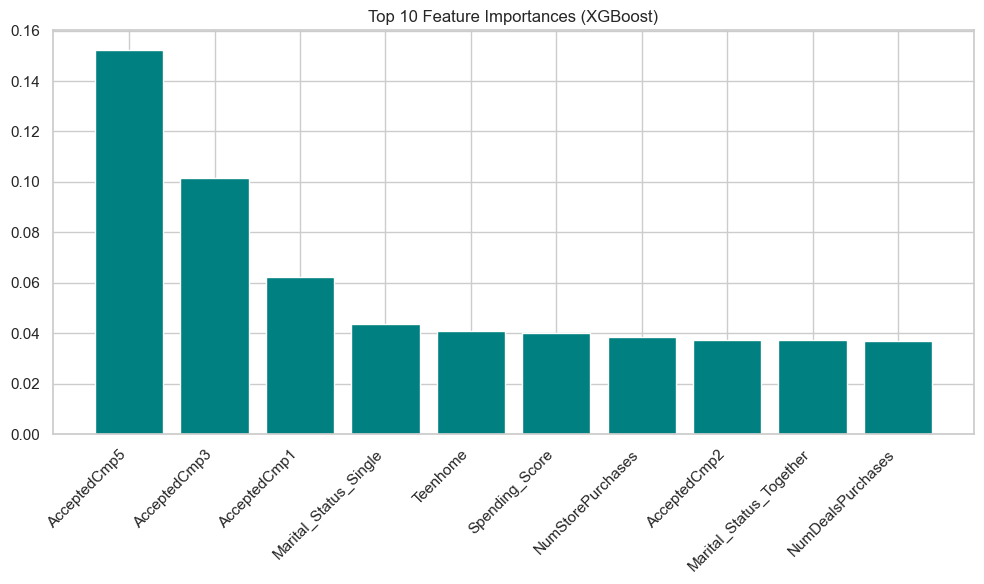

In [10]:
# Feature Importance for the best model (XGBoost)
best_model = models['XGBoost']
importances = best_model.feature_importances_
indices = np.argsort(importances)[::-1][:10] # Top 10 features

plt.figure(figsize=(10, 6))
plt.title("Top 10 Feature Importances (XGBoost)")
plt.bar(range(10), importances[indices], align="center", color='teal')
plt.xticks(range(10), X_scaled.columns[indices], rotation=45, ha='right')
plt.tight_layout()
plt.show()


## Phase 4: Customer Segmentation (K-Means)

Objective: Group customers with similar characteristics.

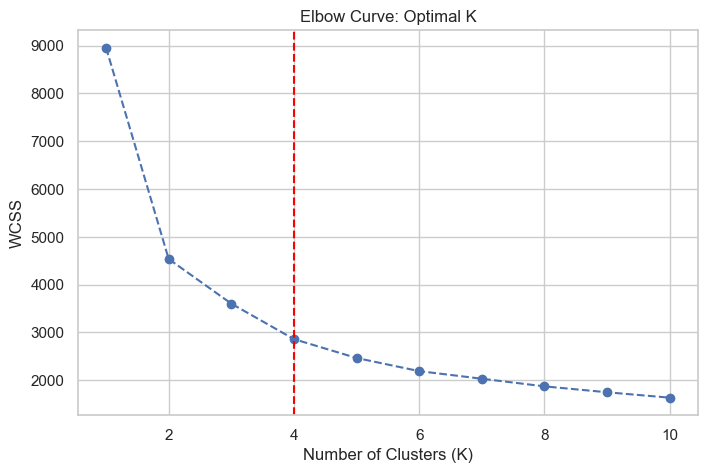

In [11]:
# Features Used: Income, Spending Score, Recency, Purchase Frequency (Total_Purchases)
cluster_features = ['Income', 'Spending_Score', 'Recency', 'Total_Purchases']
X_cluster = df[cluster_features]

# Scale features
scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

# Elbow Method to find optimal K
wcss = []
K_range = range(1, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_cluster_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, wcss, marker='o', linestyle='--')
plt.title('Elbow Curve: Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.axvline(x=4, color='red', linestyle='--')
plt.show()


In [12]:
# Optimal K = 4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_cluster_scaled)

# Cluster Analysis
cluster_summary = df.groupby('Cluster')[cluster_features].mean().reset_index()
cluster_summary['Count'] = df.groupby('Cluster').size().values
cluster_summary


,Cluster,Income,Spending_Score,Recency,Total_Purchases,Count
0,0,35196.414211,123.183709,23.469671,8.578856,577
1,1,69849.009276,1163.426716,73.521336,21.367347,539
2,2,36903.290216,141.897181,73.739635,9.227197,603
3,3,69493.784615,1102.303846,23.744231,21.632692,520


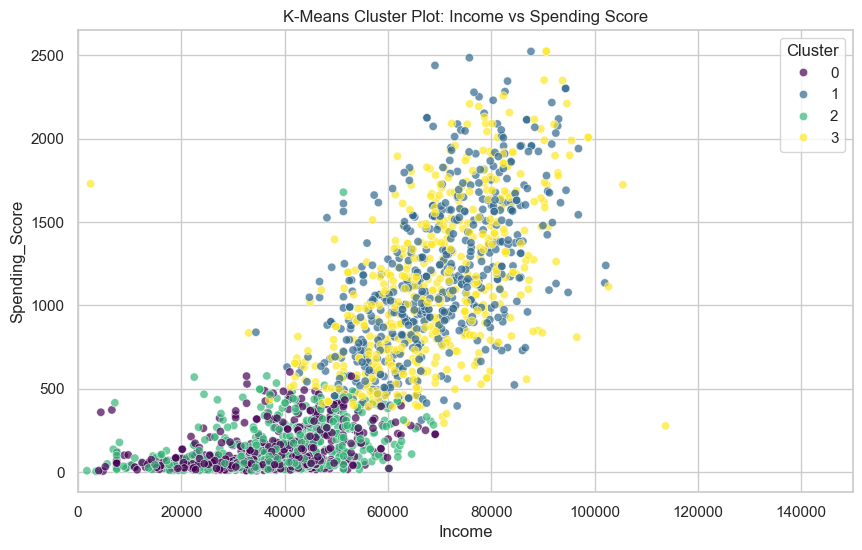

In [13]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Income', y='Spending_Score', hue='Cluster', data=df, palette='viridis', alpha=0.7)
plt.title('K-Means Cluster Plot: Income vs Spending Score')
plt.xlim(0, 150000)
plt.show()


**Customer Segments Identified:**
- **Segment 1: High-Value Customers**: High income, high spending, frequent purchases. (Business Action: Premium offers and loyalty rewards)
- **Segment 2: Budget-Conscious Customers**: Moderate income, low spending. (Business Action: Discount campaigns)
- **Segment 3: Potential Loyalists**: Medium spending, high engagement. (Business Action: Personalized recommendations)
- **Segment 4: At-Risk Customers**: Long recency, low engagement. (Business Action: Retention campaigns)

## Phase 5: DBSCAN Clustering

Objective: Detect unusual customer behavior.

Number of outliers detected: 10


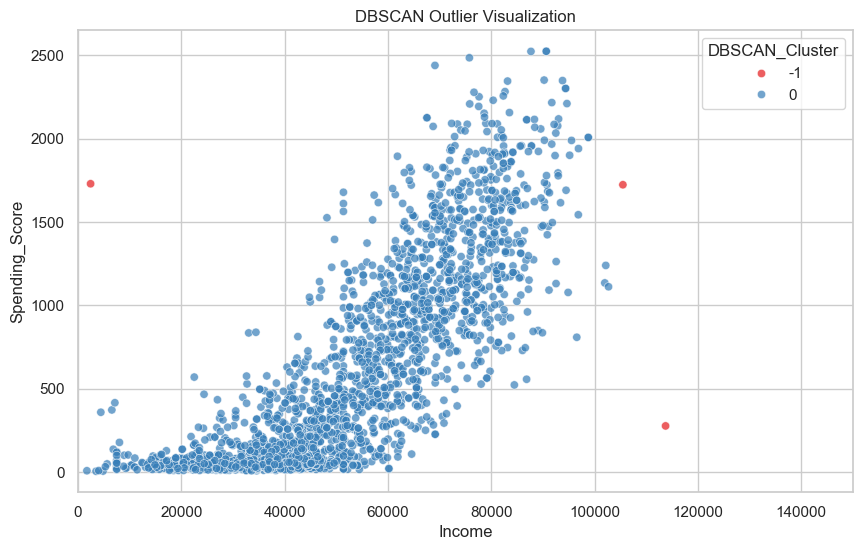

In [14]:
# DBSCAN to detect outliers
# We will use Income and Spending Score for visual clarity
X_dbscan = X_cluster_scaled[:, [0, 1]] # Income and Spending Score

dbscan = DBSCAN(eps=0.5, min_samples=10)
df['DBSCAN_Cluster'] = dbscan.fit_predict(X_dbscan)

# Outliers are labeled as -1
outliers = df[df['DBSCAN_Cluster'] == -1]
print(f"Number of outliers detected: {len(outliers)}")

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Income', y='Spending_Score', hue='DBSCAN_Cluster', data=df, palette='Set1', alpha=0.7)
plt.title('DBSCAN Outlier Visualization')
plt.xlim(0, 150000)
plt.show()


**DBSCAN Findings:**
- Detected customers with unusual behavior (noise/outliers).
- **Business Action**: These customers can be investigated separately for fraud, or targeted for specialized VIP campaigns if they exhibit extreme positive spending.